Data prepocessing 

In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import joblib

In [6]:
DATASET_PATH = "/content/drive/MyDrive/BeSafe_AI/WESAD"

In [7]:
subjects = sorted([d for d in os.listdir(DATASET_PATH) if d.startswith("S")])
subjects

['S10',
 'S11',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17',
 'S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9']

In [8]:
def load_subject(subject_id, dataset_path=DATASET_PATH):
    subject_path = os.path.join(dataset_path, subject_id, f"{subject_id}.pkl")
    with open(subject_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    return data

In [9]:
sample = load_subject("S2")
print(sample.keys())
print(sample["signal"].keys())
print(sample["signal"]["wrist"].keys())
print(np.unique(sample["label"]))

dict_keys(['signal', 'label', 'subject'])
dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
[0 1 2 3 4 6 7]


In [10]:
wrist = sample["signal"]["wrist"]

for key, value in wrist.items():
    print(key, np.array(value).shape)

ACC (194528, 3)
BVP (389056, 1)
EDA (24316, 1)
TEMP (24316, 1)


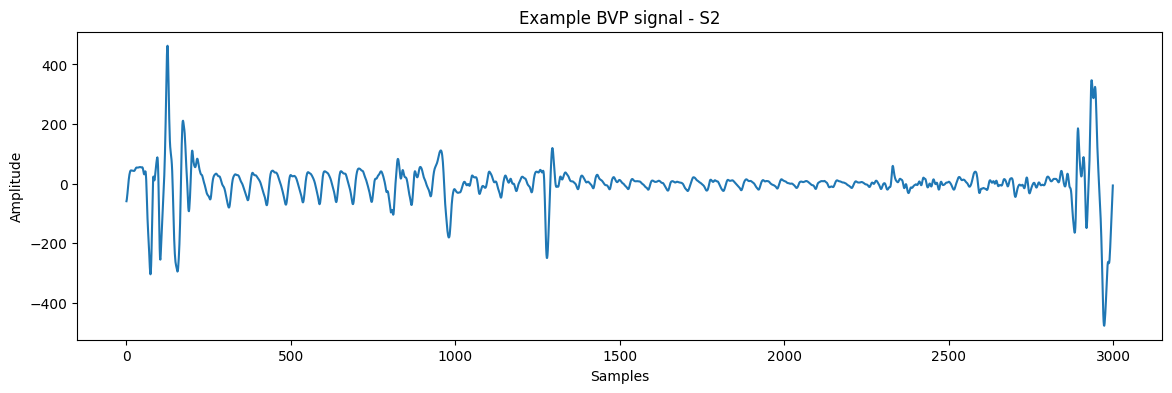

In [11]:
bvp = np.array(sample["signal"]["wrist"]["BVP"]).squeeze()

plt.figure(figsize=(14,4))
plt.plot(bvp[:3000])
plt.title("Example BVP signal - S2")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [12]:
VALID_LABELS = [1, 2]   # 1=baseline, 2=stress
LABEL_MAP = {1: 0, 2: 1}  # baseline->0, stress->1

WINDOW_SECONDS = 30
OVERLAP_SECONDS = 15

In [13]:
WRIST_FS = {
    "BVP": 64,
    "EDA": 4,
    "TEMP": 4,
    "ACC": 32
}

In [14]:
def zscore_signal(x):
    x = np.array(x, dtype=np.float32)
    std = np.std(x)
    if std < 1e-8:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

In [15]:
def acc_magnitude(acc):
    acc = np.array(acc, dtype=np.float32)
    if acc.ndim == 2 and acc.shape[1] == 3:
        return np.sqrt((acc ** 2).sum(axis=1))
    return np.array(acc).squeeze()

In [16]:
def sliding_windows(signal, window_size, step_size):
    windows = []
    starts = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])
        starts.append(start)
    return windows, starts

In [17]:
def extract_features_from_window(window, prefix="sig"):
    window = np.array(window, dtype=np.float32).squeeze()

    features = {
        f"{prefix}_mean": np.mean(window),
        f"{prefix}_std": np.std(window),
        f"{prefix}_min": np.min(window),
        f"{prefix}_max": np.max(window),
        f"{prefix}_median": np.median(window),
        f"{prefix}_range": np.max(window) - np.min(window),
        f"{prefix}_q25": np.percentile(window, 25),
        f"{prefix}_q75": np.percentile(window, 75),
        f"{prefix}_skew": stats.skew(window),
        f"{prefix}_kurtosis": stats.kurtosis(window),
        f"{prefix}_energy": np.sum(window ** 2) / len(window),
    }
    return features

In [18]:
def get_majority_label(label_segment):
    values, counts = np.unique(label_segment, return_counts=True)
    return values[np.argmax(counts)]

In [19]:
def build_subject_feature_table(subject_id, dataset_path=DATASET_PATH):
    data = load_subject(subject_id, dataset_path)

    labels_full = np.array(data["label"]).squeeze()
    wrist = data["signal"]["wrist"]

    bvp = zscore_signal(np.array(wrist["BVP"]).squeeze())
    eda = zscore_signal(np.array(wrist["EDA"]).squeeze())
    temp = zscore_signal(np.array(wrist["TEMP"]).squeeze())
    acc = zscore_signal(acc_magnitude(wrist["ACC"]))

    signal_dict = {
        "BVP": bvp,
        "EDA": eda,
        "TEMP": temp,
        "ACC": acc
    }

    rows = []

    # On choisit BVP comme signal de référence pour la fenêtre
    ref_name = "BVP"
    ref_signal = signal_dict[ref_name]
    ref_fs = WRIST_FS[ref_name]

    window_size = WINDOW_SECONDS * ref_fs
    step_size = (WINDOW_SECONDS - OVERLAP_SECONDS) * ref_fs

    ref_windows, ref_starts = sliding_windows(ref_signal, window_size, step_size)

    for i, start in enumerate(ref_starts):
        end = start + window_size

        # Conversion des indices BVP vers indices labels
        label_start = int(start / len(ref_signal) * len(labels_full))
        label_end = int(end / len(ref_signal) * len(labels_full))

        label_segment = labels_full[label_start:label_end]
        if len(label_segment) == 0:
            continue

        majority_label = get_majority_label(label_segment)

        if majority_label not in VALID_LABELS:
            continue

        feature_row = {
            "subject": subject_id,
            "label_original": int(majority_label),
            "label_binary": LABEL_MAP[int(majority_label)]
        }

        # Pour chaque signal, on récupère la fenêtre correspondante
        for sig_name, sig_data in signal_dict.items():
            sig_fs = WRIST_FS[sig_name]

            sig_start = int(start / ref_fs * sig_fs)
            sig_end = int(end / ref_fs * sig_fs)

            if sig_end > len(sig_data):
                continue

            sig_window = sig_data[sig_start:sig_end]
            if len(sig_window) < 2:
                continue

            sig_features = extract_features_from_window(sig_window, prefix=sig_name.lower())
            feature_row.update(sig_features)

        rows.append(feature_row)

    df = pd.DataFrame(rows)
    return df

In [20]:
df_s2 = build_subject_feature_table("S2")
df_s2.head()

,subject,label_original,label_binary,bvp_mean,bvp_std,bvp_min,bvp_max,bvp_median,bvp_range,bvp_q25,...,acc_std,acc_min,acc_max,acc_median,acc_range,acc_q25,acc_q75,acc_skew,acc_kurtosis,acc_energy
0,S2,1,0,0.014078,1.550655,-6.219611,7.870708,0.017338,14.090320,-0.595774,...,1.333691,-6.831200,8.262720,-0.160523,15.093920,-0.312355,0.268486,1.124414,6.362939,1.778739
1,S2,1,0,0.026997,1.649292,-5.170333,7.311999,-0.025498,12.482332,-0.802308,...,1.730581,-7.424559,13.616532,-0.089269,21.041092,-0.586625,0.745218,1.358903,8.745790,3.011286
2,S2,1,0,-0.012274,1.704886,-5.170333,7.311999,0.000006,12.482332,-0.830283,...,1.528519,-7.424559,13.616532,0.001792,21.041092,-0.412964,0.536186,1.897157,14.205643,2.355760
3,S2,1,0,-0.026699,1.113498,-4.549676,4.739219,0.054572,9.288896,-0.347590,...,0.444682,-2.818084,2.564136,-0.036917,5.382220,-0.196292,0.068852,0.704093,9.019349,0.199580
4,S2,1,0,0.011734,0.661900,-4.549676,2.766403,0.066500,7.316079,-0.277043,...,0.577829,-6.346212,3.981178,-0.092653,10.327390,-0.165627,0.035364,-1.242490,25.292538,0.337056


In [21]:
print("Shape:", df_s2.shape)
print(df_s2["label_binary"].value_counts())

Shape: (117, 47)
label_binary
0    76
1    41
Name: count, dtype: int64


ENTRAINEMENT

In [22]:
selected_subjects = ["S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9"]

all_dfs = []
for subject_id in selected_subjects:
    print(f"Processing {subject_id} ...")
    df_subj = build_subject_feature_table(subject_id)
    print(df_subj.shape)
    all_dfs.append(df_subj)

df_all = pd.concat(all_dfs, ignore_index=True)
print("Final shape:", df_all.shape)
df_all.head()

Processing S2 ...
(117, 47)
Processing S3 ...
(119, 47)
Processing S4 ...
(120, 47)
Processing S5 ...
(123, 47)
Processing S6 ...
(123, 47)
Processing S7 ...
(122, 47)
Processing S8 ...
(123, 47)
Processing S9 ...
(121, 47)
Final shape: (968, 47)


,subject,label_original,label_binary,bvp_mean,bvp_std,bvp_min,bvp_max,bvp_median,bvp_range,bvp_q25,...,acc_std,acc_min,acc_max,acc_median,acc_range,acc_q25,acc_q75,acc_skew,acc_kurtosis,acc_energy
0,S2,1,0,0.014078,1.550655,-6.219611,7.870708,0.017338,14.090320,-0.595774,...,1.333691,-6.831200,8.262720,-0.160523,15.093920,-0.312355,0.268486,1.124414,6.362939,1.778739
1,S2,1,0,0.026997,1.649292,-5.170333,7.311999,-0.025498,12.482332,-0.802308,...,1.730581,-7.424559,13.616532,-0.089269,21.041092,-0.586625,0.745218,1.358903,8.745790,3.011286
2,S2,1,0,-0.012274,1.704886,-5.170333,7.311999,0.000006,12.482332,-0.830283,...,1.528519,-7.424559,13.616532,0.001792,21.041092,-0.412964,0.536186,1.897157,14.205643,2.355760
3,S2,1,0,-0.026699,1.113498,-4.549676,4.739219,0.054572,9.288896,-0.347590,...,0.444682,-2.818084,2.564136,-0.036917,5.382220,-0.196292,0.068852,0.704093,9.019349,0.199580
4,S2,1,0,0.011734,0.661900,-4.549676,2.766403,0.066500,7.316079,-0.277043,...,0.577829,-6.346212,3.981178,-0.092653,10.327390,-0.165627,0.035364,-1.242490,25.292538,0.337056


In [23]:
print("Nombre total d'échantillons :", len(df_all))

Nombre total d'échantillons : 968


In [24]:
print(df_all["label_binary"].value_counts())

label_binary
0    623
1    345
Name: count, dtype: int64


In [25]:
df_all["label_binary"].value_counts()

,count
label_binary,
0,623
1,345


In [26]:
drop_cols = ["subject", "label_original", "label_binary"]
feature_cols = [c for c in df_all.columns if c not in drop_cols]

X = df_all[feature_cols].copy()
y = df_all["label_binary"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (968, 44)
y shape: (968,)


In [27]:
print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (968, 44)
y shape : (968,)


In [28]:
print(X.isnull().sum().sum())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
print(X.isnull().sum().sum())

0
0


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(774, 44) (194, 44) (774,) (194,)


In [30]:
print("Train samples :", len(X_train))
print("Test samples :", len(X_test))

Train samples : 774
Test samples : 194


In [31]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [32]:
y_pred = rf_model.predict(X_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Baseline", "Stress"]))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.979381443298969
F1-score: 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

    Baseline       0.98      0.99      0.98       125
      Stress       0.99      0.96      0.97        69

    accuracy                           0.98       194
   macro avg       0.98      0.97      0.98       194
weighted avg       0.98      0.98      0.98       194


Confusion Matrix:

[[124   1]
 [  3  66]]


In [34]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(20)

,feature,importance
18,eda_q75,0.148726
11,eda_mean,0.103163
13,eda_min,0.095859
14,eda_max,0.091423
15,eda_median,0.086320
17,eda_q25,0.059544
21,eda_energy,0.053713
25,temp_max,0.052390
22,temp_mean,0.048986
26,temp_median,0.044042


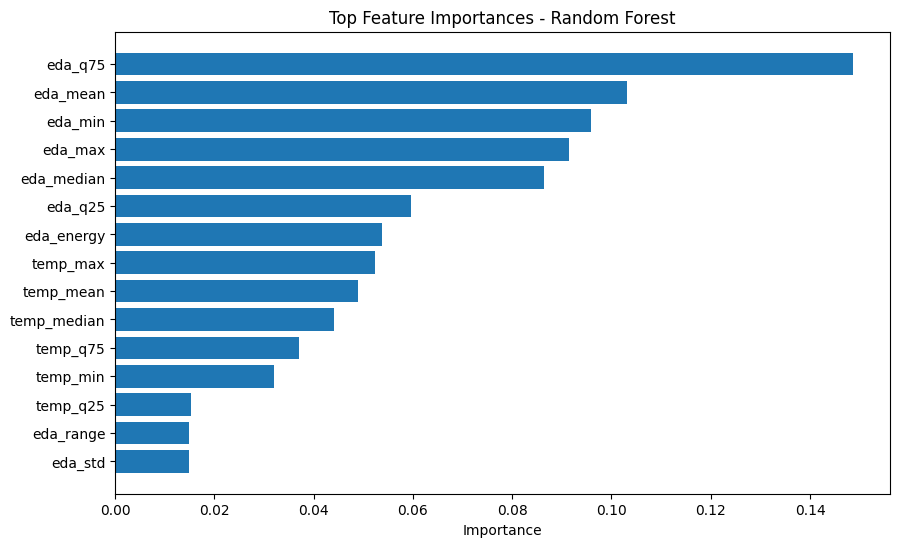

In [35]:
plt.figure(figsize=(10, 6))
top_k = 15
plt.barh(importances["feature"].head(top_k)[::-1], importances["importance"].head(top_k)[::-1])
plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

In [36]:
output_csv = "/content/drive/MyDrive/BeSafe_AI/wesad_features_random_forest.csv"
df_all.to_csv(output_csv, index=False)
print("Saved:", output_csv)

Saved: /content/drive/MyDrive/BeSafe_AI/wesad_features_random_forest.csv


In [37]:
print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
label_binary
0    498
1    276
Name: count, dtype: int64

Test class distribution:
label_binary
0    125
1     69
Name: count, dtype: int64


In [38]:
print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
label_binary
0    498
1    276
Name: count, dtype: int64

Test class distribution:
label_binary
0    125
1     69
Name: count, dtype: int64


In [ ]:
modele PKl

In [39]:
model_path = "/content/drive/MyDrive/BeSafe_AI/random_forest_wesad.pkl"
joblib.dump(rf_model, model_path)
print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/BeSafe_AI/random_forest_wesad.pkl


In [40]:
def predict_single_row(model, row_df):
    pred = model.predict(row_df)[0]
    proba = model.predict_proba(row_df)[0]
    return {
        "predicted_class": int(pred),
        "prob_baseline": float(proba[0]),
        "prob_stress": float(proba[1])
    }

In [41]:
sample_row = X_test.iloc[[0]]
result = predict_single_row(rf_model, sample_row)
result

{'predicted_class': 1,
 'prob_baseline': 0.0033333333333333335,
 'prob_stress': 0.9966666666666667}

Metrics

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.979381443298969


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       125
           1       0.99      0.96      0.97        69

    accuracy                           0.98       194
   macro avg       0.98      0.97      0.98       194
weighted avg       0.98      0.98      0.98       194



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[124   1]
 [  3  66]]


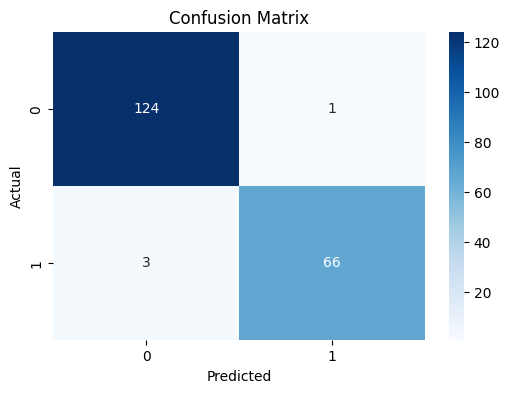

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [46]:
import pandas as pd

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importances = importances.sort_values(by="importance", ascending=False)

importances.head(10)

,feature,importance
18,eda_q75,0.148726
11,eda_mean,0.103163
13,eda_min,0.095859
14,eda_max,0.091423
15,eda_median,0.086320
17,eda_q25,0.059544
21,eda_energy,0.053713
25,temp_max,0.052390
22,temp_mean,0.048986
26,temp_median,0.044042


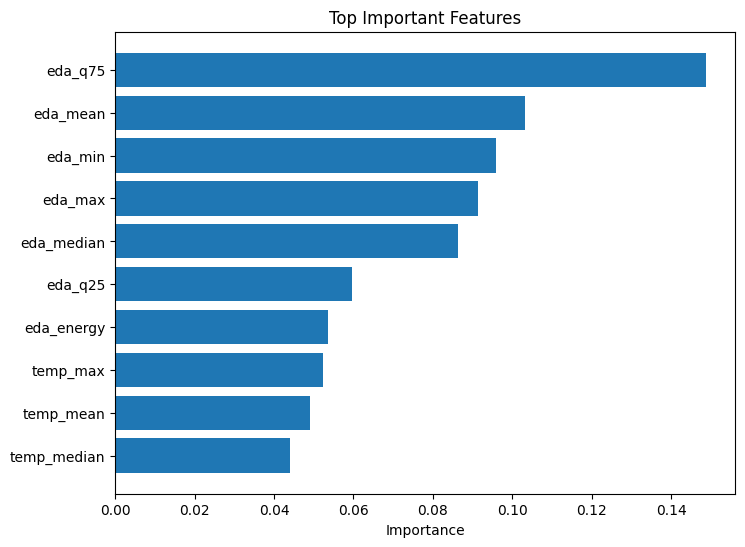

In [47]:
plt.figure(figsize=(8,6))

plt.barh(importances["feature"][:10][::-1],
         importances["importance"][:10][::-1])

plt.title("Top Important Features")
plt.xlabel("Importance")
plt.show()

In [48]:
!pip install skl2onnx onnx onnxruntime

In [49]:
import joblib
import numpy as np
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Charger ton modèle sklearn
rf_model = joblib.load("/content/drive/MyDrive/BeSafe_AI/random_forest_wesad.pkl")

# Nombre de features utilisé à l'entraînement
n_features = X_train.shape[1]

initial_type = [('float_input', FloatTensorType([None, n_features]))]

onnx_model = convert_sklearn(
    rf_model,
    initial_types=initial_type,
    target_opset=12
)

with open("/content/drive/MyDrive/BeSafe_AI/random_forest_wesad.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX model saved successfully.")

ONNX model saved successfully.
